<a href="https://colab.research.google.com/github/Geethanjali295/ML-PROJECT/blob/main/Geethanjali_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [24]:
df=pd.read_csv('/content/the_loan.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [25]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


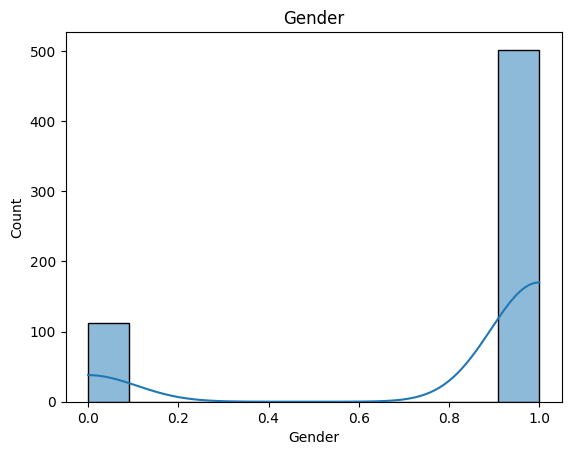

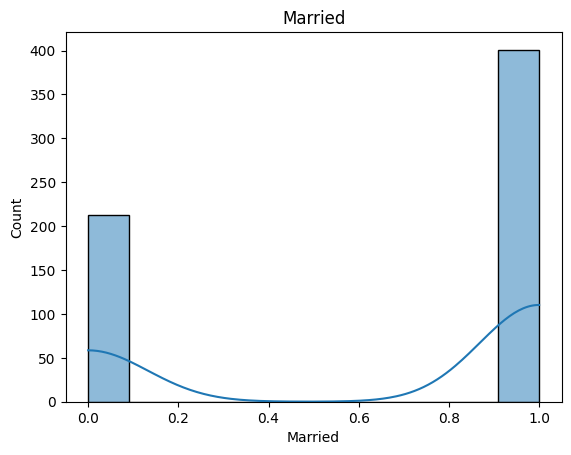

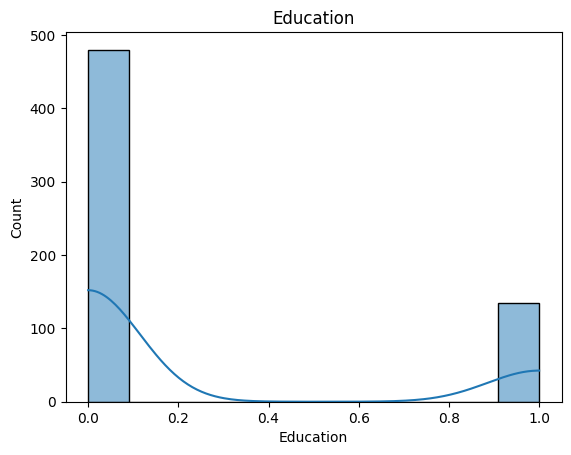

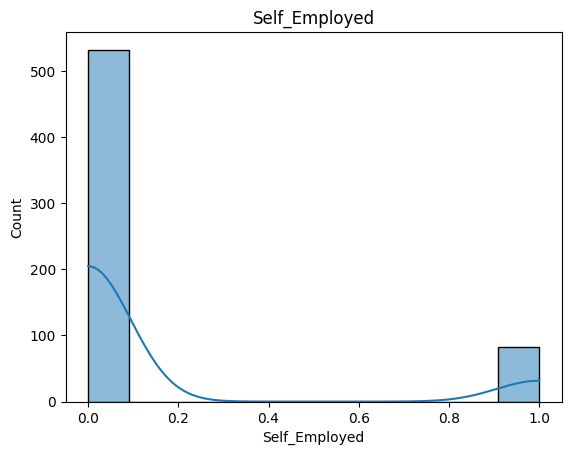

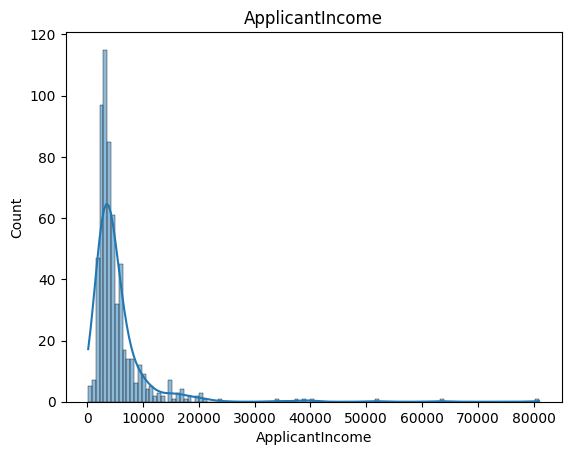

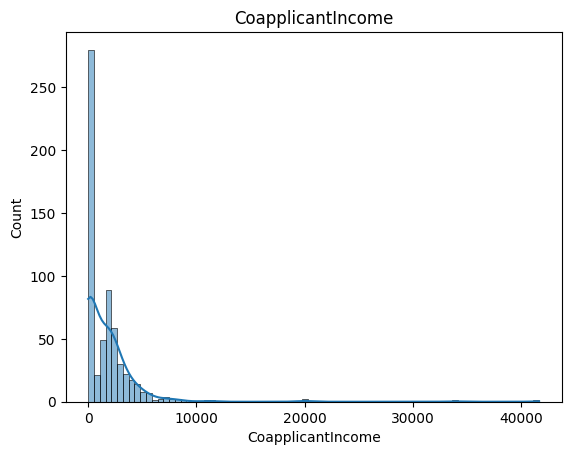

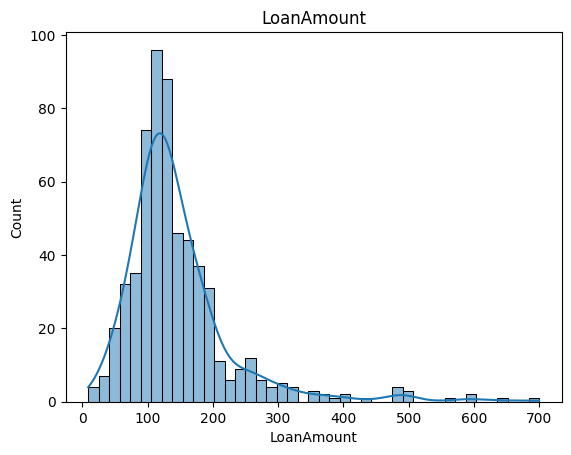

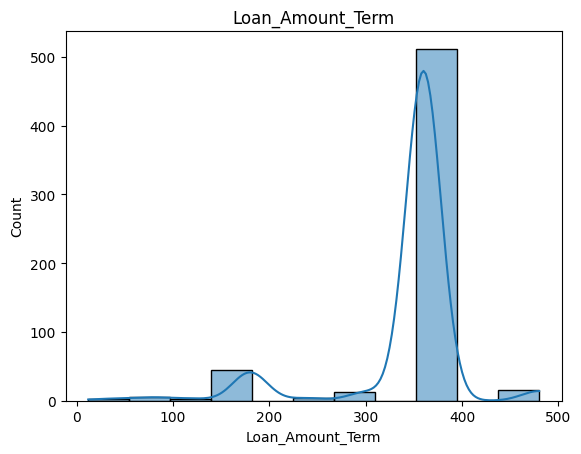

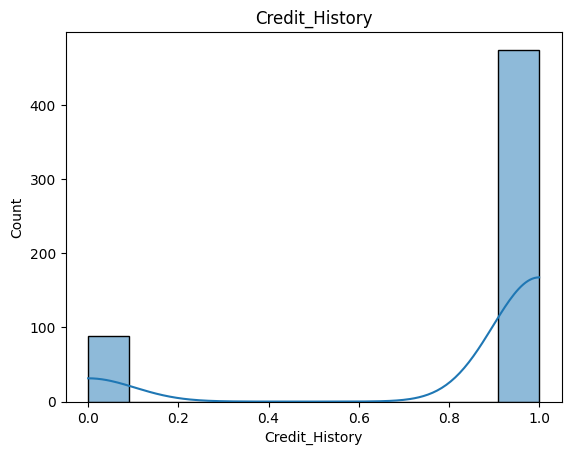

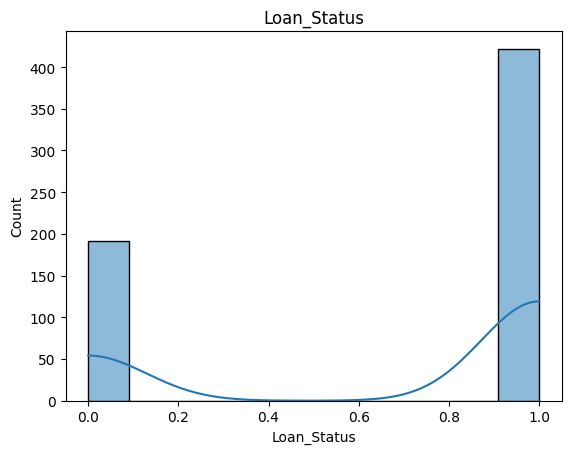

In [59]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.histplot(df[col],kde=True)
  plt.title(col)
  plt.show()

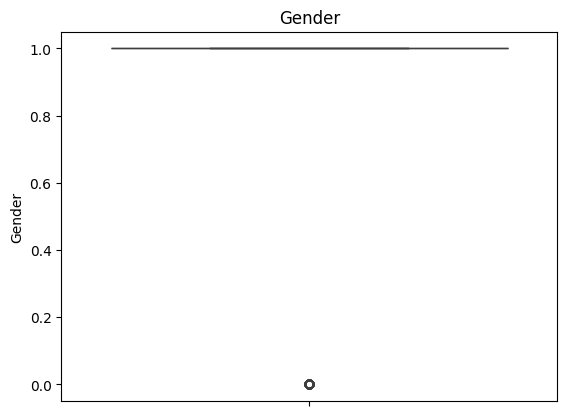

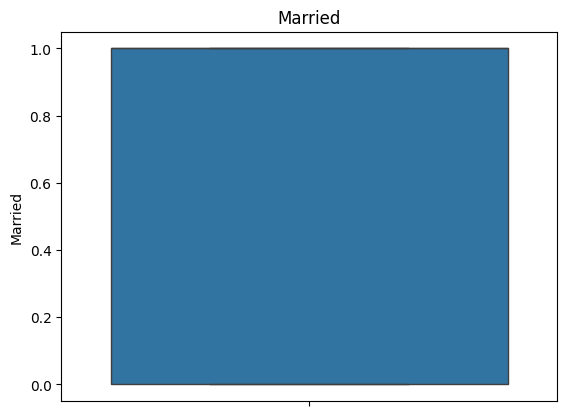

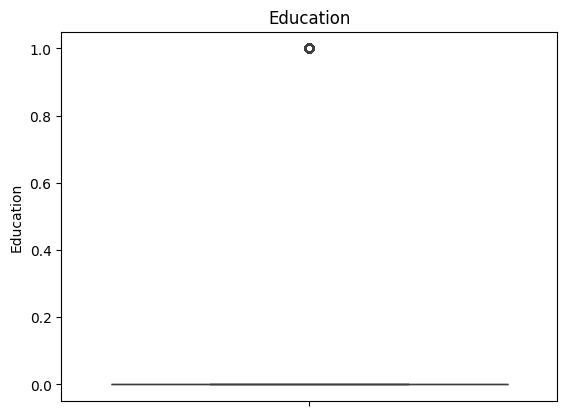

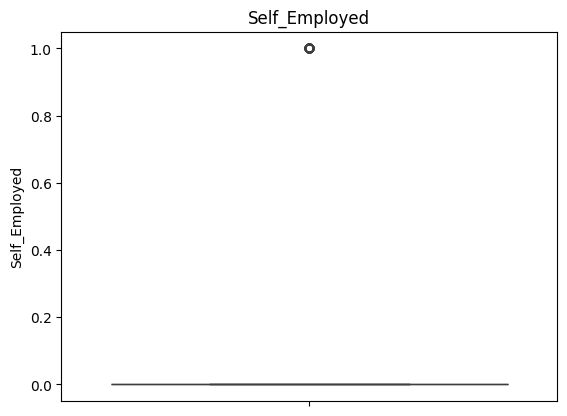

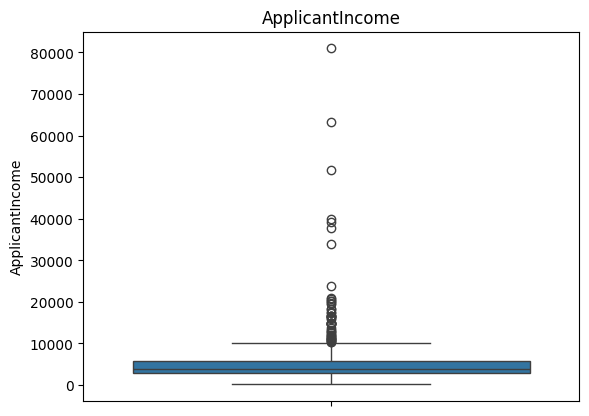

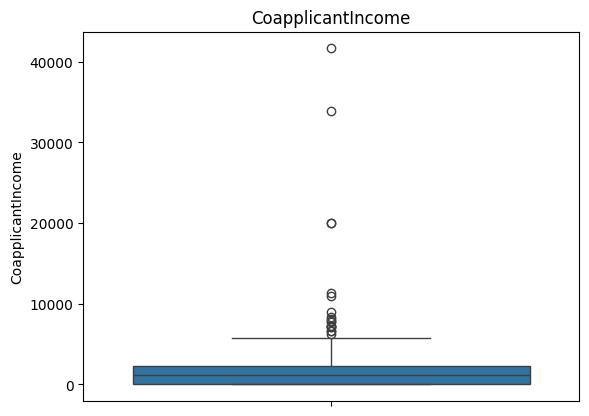

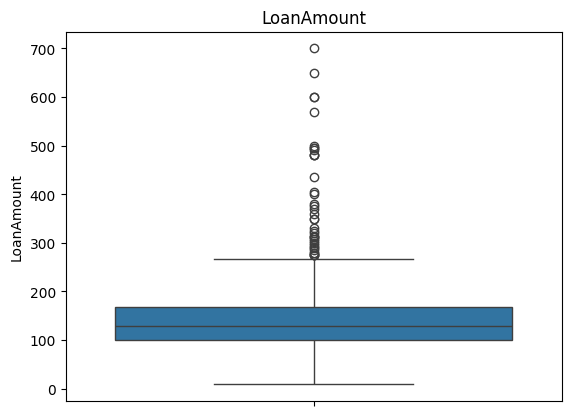

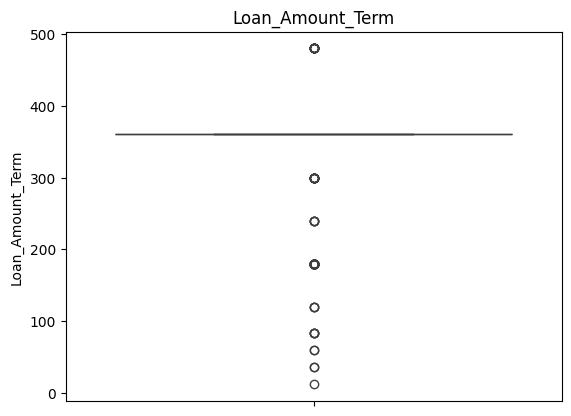

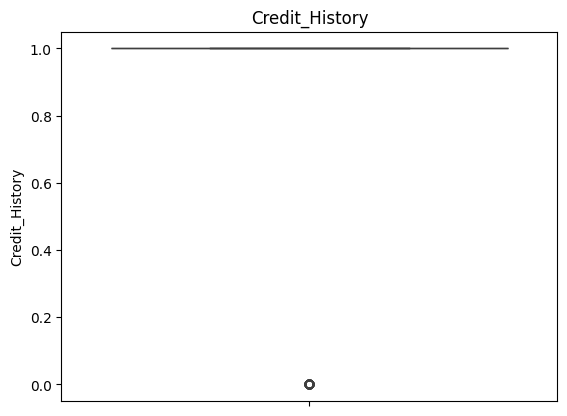

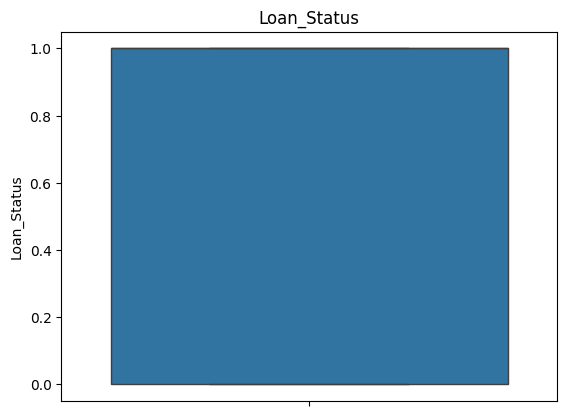

In [60]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

<Axes: >

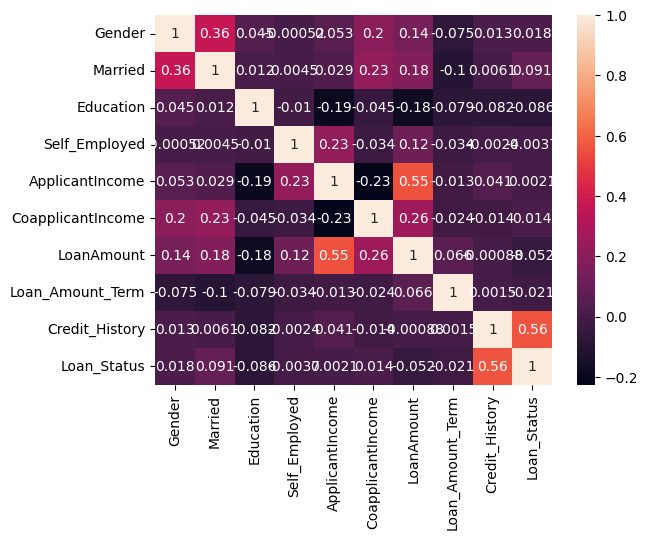

In [64]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)

In [26]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
multi_class_cols = ['Dependents', 'Property_Area']

print("LabelEncoder imported and categorical column lists defined.")

LabelEncoder imported and categorical column lists defined.


In [61]:
Q1=df['LoanAmount'].quantile(0.25)
Q3=df['LoanAmount'].quantile(0.75)
IQR=Q3-Q1

upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR
df['LoanAmount']=np.where(df['LoanAmount']>upper_bound,upper_bound,df['LoanAmount'])
df['LoanAmount']=np.where(df['LoanAmount']<lower_bound,lower_bound,df['LoanAmount'])
print("outliers in 'LoanAmount' column treated using IQR method")
df.head()

outliers in 'LoanAmount' column treated using IQR method


,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,0,5849,0.0,NaN,360.0,1.0,1,False,False,False,False,True
1,LP001003,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,True,False,False,False,False
2,LP001005,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,False,False,False,False,True
3,LP001006,1,1,1,0,2583,2358.0,120.0,360.0,1.0,1,False,False,False,False,True
4,LP001008,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,False,False,False,True


In [63]:
from scipy.stats.mstats import winsorize
df['ApplicantIncome']=winsorize(df['ApplicantIncome'],(0,0.05))
df['CoapplicantIncome']=winsorize(df['CoapplicantIncome'],(0,0.05))

df.head()

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,0,5849,0.0,NaN,360.0,1.0,1,False,False,False,False,True
1,LP001003,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,True,False,False,False,False
2,LP001005,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,False,False,False,False,True
3,LP001006,1,1,1,0,2583,2358.0,120.0,360.0,1.0,1,False,False,False,False,True
4,LP001008,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,False,False,False,True


In [27]:
label_encoder = LabelEncoder()
for col in binary_cols:
    if col in df.columns:
        # Fill missing values before encoding, if any, with the mode
        df[col] = df[col].fillna(df[col].mode()[0])
        df[col] = label_encoder.fit_transform(df[col])
    else:
        print(f"Column '{col}' not found in DataFrame.")

print("Binary categorical columns encoded.")

Binary categorical columns encoded.


In [28]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
for col in multi_class_cols:
    if col in df.columns:

        df[col] = df[col].fillna(df[col].mode()[0])

        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(col, axis=1)
    else:
        print(f"Column '{col}' not found in DataFrame.")

print("Multi-class categorical columns one-hot encoded.")

Multi-class categorical columns one-hot encoded.


In [65]:
bool_cols=df.select_dtypes(include='bool').columns
df[bool_cols]=df[bool_cols].astype(int)
df

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,0,5849,0.0,NaN,360.0,1.0,1,0,0,0,0,1
1,LP001003,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,LP001005,1,1,0,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,0,1
3,LP001006,1,1,1,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,0,1
4,LP001008,1,0,0,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,0,2900,0.0,71.0,360.0,1.0,1,0,0,0,0,0
610,LP002979,1,1,0,0,4106,0.0,40.0,180.0,1.0,1,0,0,1,0,0
611,LP002983,1,1,0,0,8072,240.0,253.0,360.0,1.0,1,1,0,0,0,1
612,LP002984,1,1,0,0,7583,0.0,187.0,360.0,1.0,1,0,1,0,0,1


In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(['Loan_Status', 'Loan_ID'], axis=1)
y = df['Loan_Status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (491, 14)
X_test shape: (123, 14)
y_train shape: (491,)
y_test shape: (123,)


In [30]:
numerical_cols_to_scale = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

median_loan_amount_train = X_train['LoanAmount'].median()
median_loan_amount_term_train = X_train['Loan_Amount_Term'].median()
mode_credit_history_train = X_train['Credit_History'].mode()[0]

print(f"Median LoanAmount from X_train: {median_loan_amount_train}")
print(f"Median Loan_Amount_Term from X_train: {median_loan_amount_term_train}")
print(f"Mode Credit_History from X_train: {mode_credit_history_train}")

Median LoanAmount from X_train: 129.0
Median Loan_Amount_Term from X_train: 360.0
Mode Credit_History from X_train: 1.0


In [31]:
X_train['LoanAmount'].fillna(median_loan_amount_train, inplace=True)
X_test['LoanAmount'].fillna(median_loan_amount_train, inplace=True)

X_train['Loan_Amount_Term'].fillna(median_loan_amount_term_train, inplace=True)
X_test['Loan_Amount_Term'].fillna(median_loan_amount_term_train, inplace=True)

X_train['Credit_History'].fillna(mode_credit_history_train, inplace=True)
X_test['Credit_History'].fillna(mode_credit_history_train, inplace=True)

print("Missing numerical values in X_train and X_test imputed.")

Missing numerical values in X_train and X_test imputed.


/tmp/ipykernel_522/3585013782.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['LoanAmount'].fillna(median_loan_amount_train, inplace=True)
/tmp/ipykernel_522/3585013782.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [32]:
X_train['LoanAmount'] = X_train['LoanAmount'].fillna(median_loan_amount_train)
X_test['LoanAmount'] = X_test['LoanAmount'].fillna(median_loan_amount_train)

X_train['Loan_Amount_Term'] = X_train['Loan_Amount_Term'].fillna(median_loan_amount_term_train)
X_test['Loan_Amount_Term'] = X_test['Loan_Amount_Term'].fillna(median_loan_amount_term_train)

X_train['Credit_History'] = X_train['Credit_History'].fillna(mode_credit_history_train)
X_test['Credit_History'] = X_test['Credit_History'].fillna(mode_credit_history_train)

print("Missing numerical values in X_train and X_test imputed.")

Missing numerical values in X_train and X_test imputed.


In [33]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("Numerical features scaled in X_train and X_test.")

Numerical features scaled in X_train and X_test.


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [43]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear')}



In [44]:
for name, model in models.items():


    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

In [45]:
accuracy

0.7886178861788617

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [47]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)}

In [48]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

Accuracy: 0.6829
Precision: 0.7356
Recall: 0.8000
F1-Score: 0.7665
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.47      0.51        43
           1       0.74      0.80      0.77        80

    accuracy                           0.68       123
   macro avg       0.65      0.63      0.64       123
weighted avg       0.67      0.68      0.68       123

Accuracy: 0.7724
Precision: 0.7600
Recall: 0.9500
F1-Score: 0.8444
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.44      0.58        43
           1       0.76      0.95      0.84        80

    accuracy                           0.77       123
   macro avg       0.79      0.70      0.71       123
weighted avg       0.78      0.77      0.75       123



In [49]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}
print("Hyperparameter grid for Random Forest defined.")

Hyperparameter grid for Random Forest defined.


In [50]:
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2)

print("GridSearchCV initialized with RandomForestClassifier and hyperparameter grid.")

GridSearchCV initialized with RandomForestClassifier and hyperparameter grid.


In [51]:
grid_search.fit(X_train, y_train)

print("GridSearchCV fitting complete.")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
GridSearchCV fitting complete.
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Best F1 score: 0.8792


In [52]:
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\nEvaluation of Tuned Random Forest Model:")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-Score: {f1_tuned:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))


Evaluation of Tuned Random Forest Model:
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
Accuracy: 0.7805
Precision: 0.7573
Recall: 0.9750
F1-Score: 0.8525
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123

